In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [45]:
df = pd.read_csv("/content/loan_risk_prediction_dataset.cvc.csv")
df

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0
...,...,...,...,...,...,...,...,...,...,...
4995,24,36780.0,23383.0,NaN,23,Male,Masters,Houston,Salaried,0
4996,66,99146.0,9760.0,306.0,14,Male,PhD,New York,Unemployed,0
4997,26,58100.0,18230.0,311.0,10,Female,High School,San Francisco,Self-Employed,0
4998,53,58513.0,12373.0,813.0,23,Male,PhD,Houston,Salaried,1


In [5]:
df.shape

(5000, 10)

In [6]:
df.dtypes

,0
Age,int64
Income,float64
LoanAmount,float64
CreditScore,float64
YearsExperience,int64
Gender,object
Education,object
City,object
EmploymentType,object
LoanApproved,int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [8]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [9]:
df.isnull().sum()

,0
Age,0
Income,196
LoanAmount,0
CreditScore,194
YearsExperience,0
Gender,0
Education,198
City,0
EmploymentType,0
LoanApproved,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop(columns=["Education"], inplace=True)

In [12]:
# Missing indicator
df["is_income_missing"] = (
    df["Income"]
    .isnull()
    .isnull()
    .astype(int))

In [13]:
# Missing indicator
df["is_Credit_Score_missing"] = (
    df["CreditScore"]
    .isnull()
     .astype(int))

In [21]:
# Fill missing values
df["Income"] = (
    df["Income"]
    .fillna(-1)
)

In [22]:
# Fill missing values
df["CreditScore"] = (
    df["CreditScore"]
    .fillna(-1)
)

In [23]:
df.isnull().sum()

,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
YearsExperience,0
Gender,0
City,0
EmploymentType,0
LoanApproved,0
is_income_missing,0


In [25]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

In [26]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved,is_income_missing,is_Credit_Score_missing
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,43.584600,47788.349400,19870.768600,553.126600,19.599000,0.230200,0.03920,0.038800
std,14.919094,17672.203867,8046.542413,192.804093,11.516837,0.421003,0.19409,0.193137
min,18.000000,-3731.000000,-10059.000000,-1.000000,0.000000,0.000000,0.00000,0.000000
25%,31.000000,38280.000000,14455.250000,416.000000,10.000000,0.000000,0.00000,0.000000
50%,43.000000,48662.000000,19842.500000,566.000000,20.000000,0.000000,0.00000,0.000000
75%,56.000000,59447.000000,25326.750000,706.000000,29.000000,0.000000,0.00000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000,1.00000,1.000000


In [28]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'Age': 0, 'Income': 220, 'LoanAmount': 32, 'CreditScore': 0, 'YearsExperience': 0, 'LoanApproved': 1151, 'is_income_missing': 196, 'is_Credit_Score_missing': 194}


In [29]:
import pandas as pd

outlier_df = pd.DataFrame(list(outlier_summary.items()),
                         columns=['Column', 'Outlier_Count'])

outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)

print(outlier_df)

                    Column  Outlier_Count
5             LoanApproved           1151
1                   Income            220
6        is_income_missing            196
7  is_Credit_Score_missing            194
2               LoanAmount             32
0                      Age              0
3              CreditScore              0
4          YearsExperience              0


In [30]:
outlier_df['Percentage'] = (outlier_df['Outlier_Count'] / len(df)) * 100

print(outlier_df)

                    Column  Outlier_Count  Percentage
5             LoanApproved           1151       23.02
1                   Income            220        4.40
6        is_income_missing            196        3.92
7  is_Credit_Score_missing            194        3.88
2               LoanAmount             32        0.64
0                      Age              0        0.00
3              CreditScore              0        0.00
4          YearsExperience              0        0.00


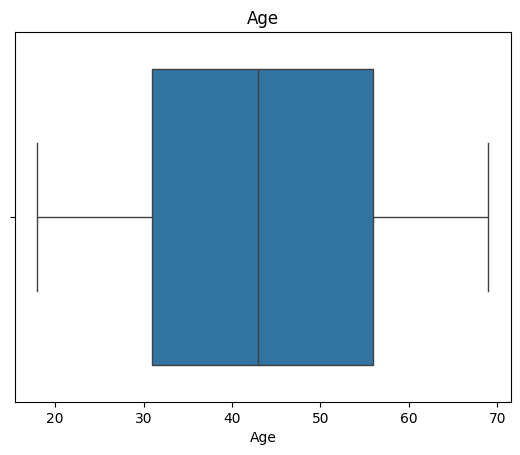

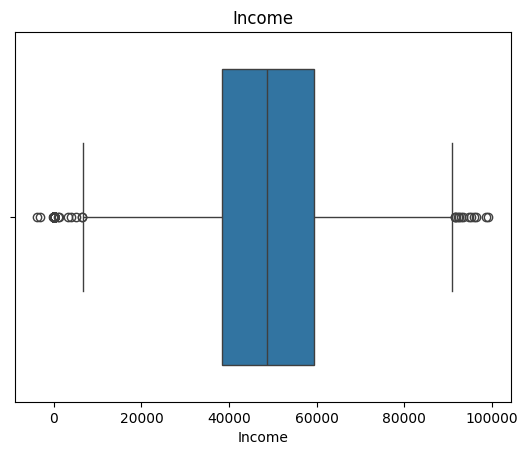

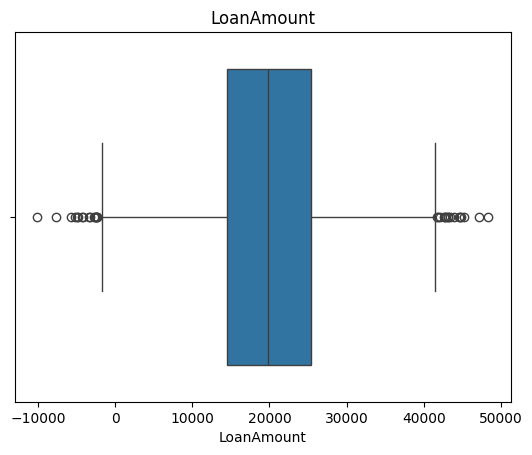

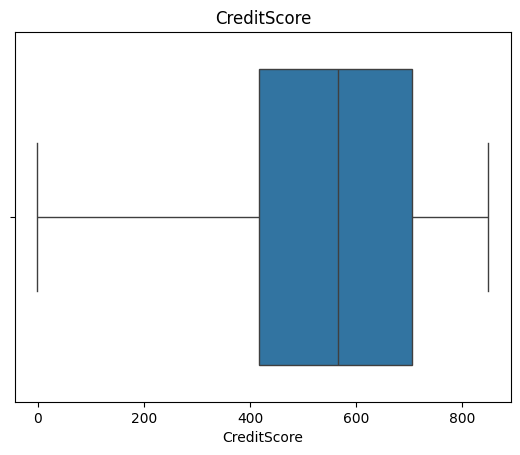

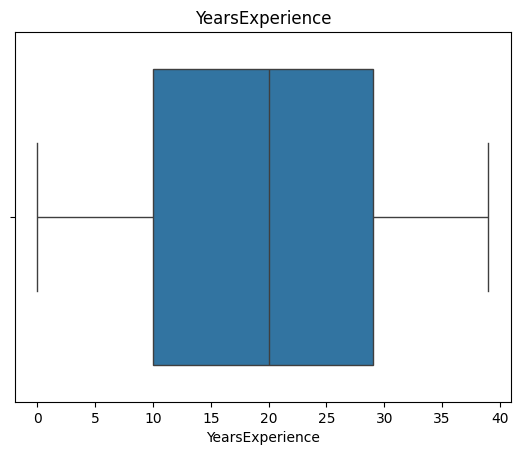

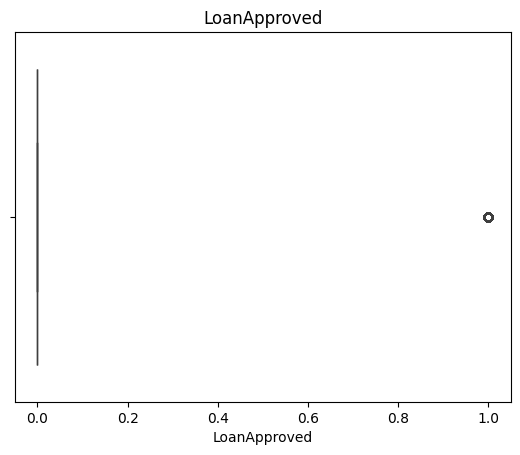

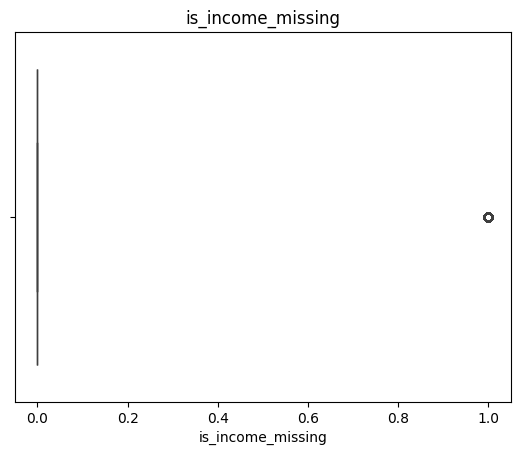

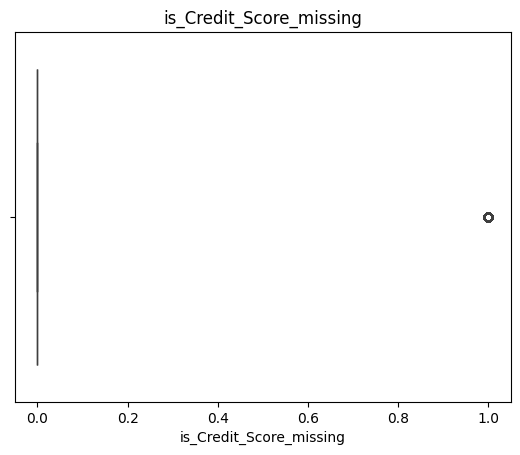

In [31]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [41]:
cols_to_cap = [
    'Income',
    'LoanAmount',
    'CreditScore',
    'YearsExperience',
    'LoanApproved',
    'is_income_missing',
    'is_Credit_Score_missing'
]

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

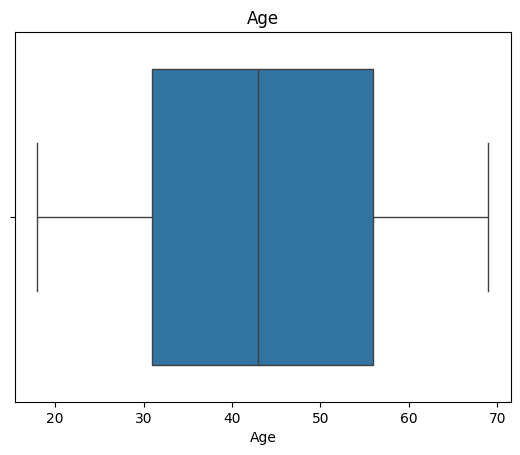

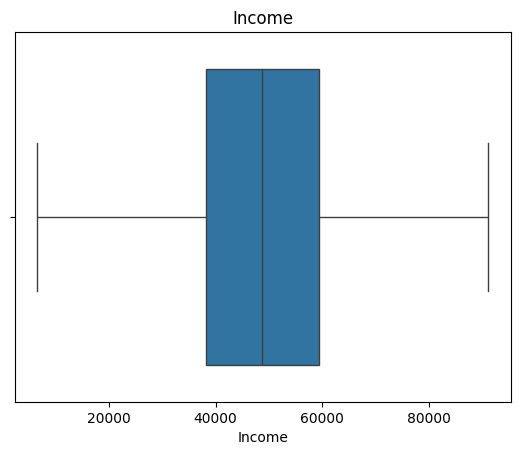

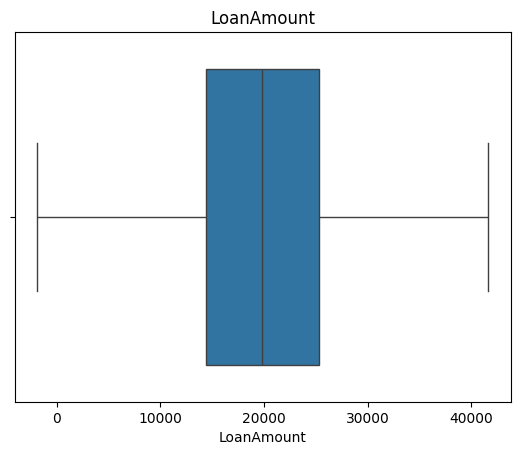

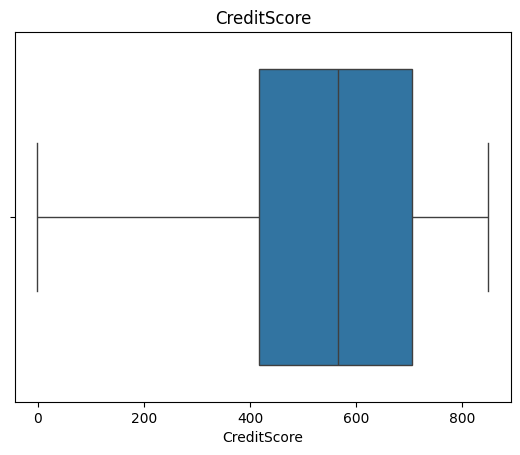

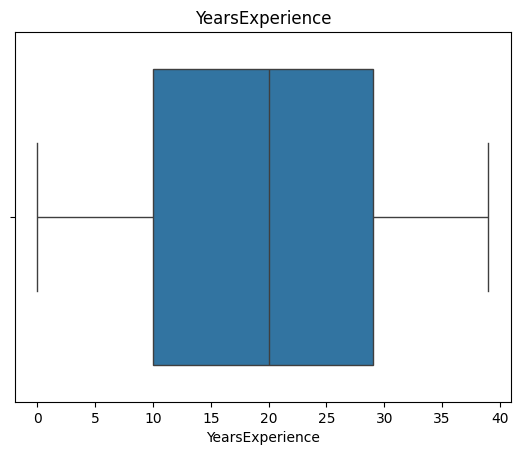

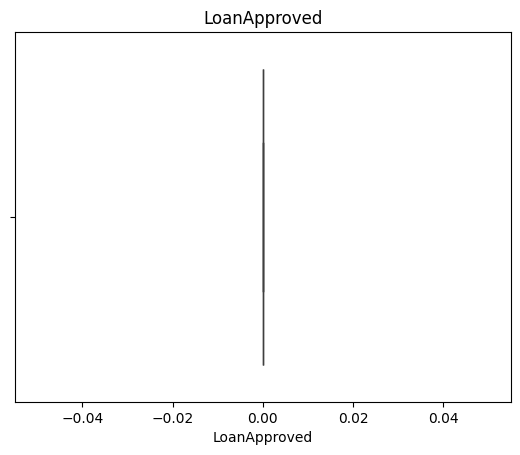

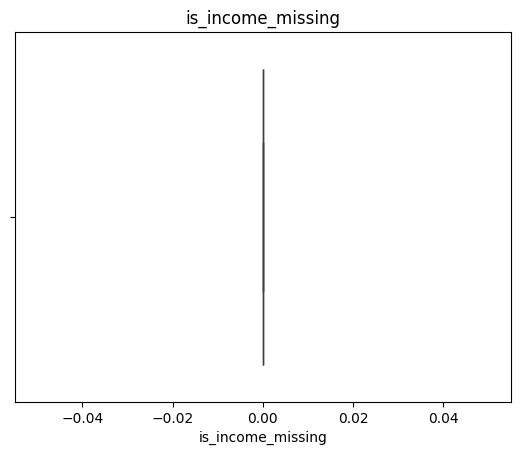

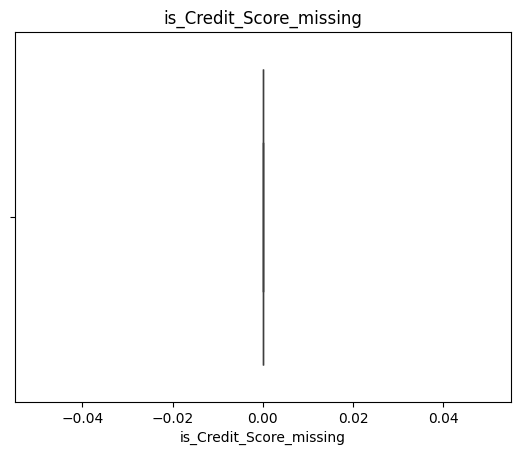

In [42]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [54]:
nominal_cols = ["Gender", "City", "EmploymentType"]
existing_cols = [col for col in nominal_cols if col in df.columns]

df = pd.get_dummies(df, columns=existing_cols, drop_first=True)


In [57]:
df.dtypes

,0
Age,int64
Income,float64
LoanAmount,float64
CreditScore,float64
YearsExperience,int64
LoanApproved,int64
Gender_Male,bool
Education_High School,bool
Education_Masters,bool
Education_PhD,bool


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features & target
X = df.drop('Education_High School', axis=1)
y = df['Education_High School']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Select numeric columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Scaling
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [63]:
print(X_train.isna().sum())


Age                               0
Income                          153
LoanAmount                        0
CreditScore                     151
YearsExperience                   0
LoanApproved                      0
Gender_Male                       0
Education_Masters                 0
Education_PhD                     0
City_Houston                      0
City_New York                     0
City_San Francisco                0
EmploymentType_Self-Employed      0
EmploymentType_Unemployed         0
dtype: int64


In [64]:
from sklearn.linear_model import LogisticRegression

# Train aur Test sets mein se saari bachi hui missing values khatam karein
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

# Model banayein aur train karein
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)
print("Model successfully trained!")


Model successfully trained!


In [66]:
y_pred = log_model.predict(X_test)

In [67]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.72


In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       1.00      0.63      0.77       762
        True       0.46      1.00      0.63       238

    accuracy                           0.72      1000
   macro avg       0.73      0.82      0.70      1000
weighted avg       0.87      0.72      0.74      1000



In [69]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[482 280]
 [  0 238]]


In [70]:
y_prob = log_model.predict_proba(X_test)[:, 1]

In [71]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [72]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

AUC Score: 0.8131354904166392


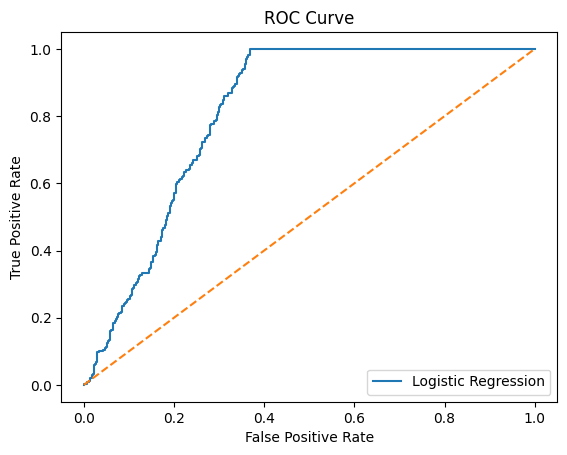

In [73]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()